# Neural Networks (PyTorch) 🧠
This notebook demonstrates a simple Neural Network using PyTorch.

C:\Users\thoma\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4324.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


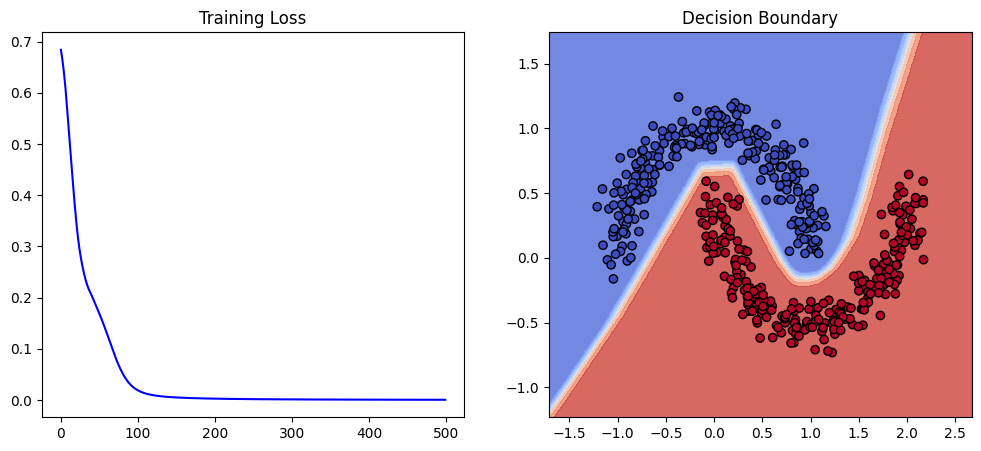

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
X_t = torch.FloatTensor(X)
y_t = torch.FloatTensor(y).reshape(-1, 1)

model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

losses = []
for epoch in range(500):
    optimizer.zero_grad()
    outputs = model(X_t)
    loss = criterion(outputs, y_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses, color='blue')
plt.title('Training Loss')

plt.subplot(1, 2, 2)
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = torch.meshgrid(torch.linspace(x_min, x_max, 100), torch.linspace(y_min, y_max, 100))
with torch.no_grad():
    Z = model(torch.cat([xx.reshape(-1, 1), yy.reshape(-1, 1)], 1)).reshape(xx.shape)
plt.contourf(xx.numpy(), yy.numpy(), Z.numpy(), alpha=0.8, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')
plt.title('Decision Boundary')
plt.show()
